# Discrete Mathematics — Section 8.3  
# Divide-and-Conquer Algorithms and Recurrence Relations

Many efficient algorithms follow a simple but powerful strategy:

Divide the problem into smaller pieces, solve those pieces recursively, and combine the results.

This strategy is known as **divide-and-conquer**.

Instead of solving a problem of size `n` directly, we solve several smaller problems of size `n/b`, then combine their solutions.

The running time of these algorithms is typically described using **recurrence relations**.

A common form is:

f(n) = a f(n/b) + g(n)

where

a = number of subproblems  
b = reduction factor  
g(n) = extra work performed during the combine step

Examples of divide-and-conquer algorithms include:

• Binary Search  
• Finding Maximum and Minimum  
• Merge Sort  
• Fast Integer Multiplication  
• Fast Matrix Multiplication (Strassen)

In this notebook we will:

1. Implement divide-and-conquer algorithms in Python
2. Measure their behavior experimentally
3. Compare empirical results with theoretical recurrence relations
4. Explore how the **Master Theorem** predicts algorithm complexity

The goal is to connect **mathematical recurrence relations** with **real programs**.

# Environment Setup (Mac / Linux)

This notebook expects the **SwosuCsPythonExamples** virtual environment.

Open a terminal and navigate to the repository directory.

## If the `.venv` already exists

Activate it:

```bash
source .venv/bin/activate
````

You should now see something like:

```
(.venv) username@machine
```

Then start Jupyter:

```bash
jupyter notebook
```

or

```bash
jupyter lab
```

---

## If the `.venv` does NOT exist

Create it and install required tools:

```bash
python3 -m venv .venv
```

Activate it:

```bash
source .venv/bin/activate
```

Upgrade pip and install packages:

```bash
pip install --upgrade pip
pip install jupyter matplotlib pandas numpy
```

Then launch Jupyter:

```bash
jupyter notebook
```

# Environment Setup (Windows)

Windows PowerShell may block the virtual environment activation script the first
time you run it. This is normal and easy to fix.

Open **PowerShell** in the repository directory.

Example:

PS C:\Users\evertj\git\SwosuCsPythonExamples>

---

# Step 1 — Create the Virtual Environment (if needed)

If `.venv` does not exist, create it:

```powershell
python -m venv .venv
````

This creates a local Python environment inside the repository.

---

# Step 2 — Allow Script Execution (One-Time Fix)

PowerShell blocks activation scripts by default.

Run the following command **once** to allow locally created scripts:

```powershell
Set-ExecutionPolicy -Scope CurrentUser -ExecutionPolicy RemoteSigned
```

When prompted, type:

```
Y
```

This setting allows scripts created on your computer (like `.venv`) to run.

---

# Step 3 — Activate the Virtual Environment

```powershell
.\.venv\Scripts\Activate.ps1
```

If activation worked, your prompt should change to something like:

```
(.venv) PS C:\Users\evertj\git\SwosuCsPythonExamples>
```

---

# Step 4 — Install Required Packages

Install the tools used in these notebooks:

```powershell
pip install --upgrade pip
pip install jupyter matplotlib pandas numpy
```

---

# Step 5 — Start Jupyter

```powershell
jupyter notebook
```

or

```powershell
jupyter lab
```

Your browser should open automatically.

---

# Alternative (No Policy Change Required)

If you cannot change execution policy (for example on a managed lab computer),
you can activate the environment using **Command Prompt instead of PowerShell**.

Open **Command Prompt** and run:

```
.venv\Scripts\activate.bat
```

Then start Jupyter:

```
jupyter notebook
```

---

Once your environment is active, run the next cell to verify that everything is working.

```

---

# Why this is the correct solution

PowerShell blocks scripts because of this setting:

```

ExecutionPolicy = Restricted

```

The command we used changes it to:

```

RemoteSigned

````

Meaning:

| Script Source | Allowed |
|---|---|
| Local scripts | ✔ |
| Downloaded scripts | Must be signed |

That is **the standard Python recommendation for Windows dev machines**.

---

# One small improvement for your notebook flow

Your **environment check cell** is perfect, but I recommend this version because it also confirms the `.venv` is active:

```python
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("Python executable:")
print(sys.executable)

print("\nPython version:", sys.version.split()[0])
print("NumPy version:", np.__version__)
print("Pandas version:", pd.__version__)

print("\nEnvironment check successful.")
print("You are ready to begin the lab.")
````

Students will see something like:

```
Python executable:
C:\Users\evertj\git\SwosuCsPythonExamples\.venv\Scripts\python.exe
```

which confirms they are **not accidentally using system Python**.



In [2]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("Python version:", sys.version)
print("NumPy version:", np.__version__)
print("Pandas version:", pd.__version__)

print("\nEnvironment check successful.")
print("If you see this message, you are ready to begin.")

Python version: 3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]
NumPy version: 2.4.3
Pandas version: 3.0.1

Environment check successful.
If you see this message, you are ready to begin.


Expected output should look something like:

Python version: 3.x.x
NumPy version: 1.xx.x
Pandas version: 2.x.x

Environment check successful.
If you see this message, you are ready to begin.

# Binary Search — Divide and Conquer Example

Binary search is a classic divide-and-conquer algorithm used to locate a value in a **sorted list**.

Instead of scanning every element, binary search repeatedly cuts the search space in half.

Steps of the algorithm:

1. Look at the **middle element** of the list.
2. If it equals the target, we are done.
3. If the target is smaller, search the **left half**.
4. If the target is larger, search the **right half**.
5. Repeat until the value is found or the list is empty.

Because the list is halved each step, the number of comparisons grows very slowly.

The recurrence relation describing binary search is:

f(n) = f(n/2) + 1

This leads to a runtime complexity of:

O(log n)

In this example we will:

• implement binary search  
• count how many comparisons occur  
• observe how the algorithm behaves as the list size increases

In [10]:
import random

def binary_search(arr, target):
    """
    Perform binary search on a sorted list.

    Returns:
        index of target (or -1 if not found)
        number of comparisons performed
    """

    low = 0
    high = len(arr) - 1
    comparisons = 0

    while low <= high:

        mid = (low + high) // 2
        comparisons += 1

        if arr[mid] == target:
            return mid, comparisons

        comparisons += 1

        if target < arr[mid]:
            high = mid - 1
        else:
            low = mid + 1

    return -1, comparisons


# Demonstration

n = 1_000_000
arr = list(range(n))

target = random.choice(arr)

index, comparisons = binary_search(arr, target)

print("List size:", n)
print("Target:", target)
print("Found at index:", index)
print("Comparisons:", comparisons)

List size: 1000000
Target: 420954
Found at index: 420954
Comparisons: 35


List size: 1000000
Target: 448244
Found at index: 448244
Comparisons: 39

List size: 100000
Target: 74321
Found at index: 74321
Comparisons: 31

List size: 10000
Target: 5598
Found at index: 5598
Comparisons: 27

List size: 1000
Target: 324
Found at index: 324
Comparisons: 17

List size: 100
Target: 88
Found at index: 88
Comparisons: 11


In [13]:
results = []

for _ in range(1000):
    target = random.choice(arr)
    _, comparisons = binary_search(arr, target)
    results.append(comparisons)

print("Min comparisons:", min(results))
print("Max comparisons:", max(results))
print("Average comparisons:", sum(results)/len(results))

Min comparisons: 15
Max comparisons: 39
Average comparisons: 36.908


Min comparisons: 9
Max comparisons: 39
Average comparisons: 36.736

Min comparisons: 9
Max comparisons: 39
Average comparisons: 36.878

Min comparisons: 15
Max comparisons: 39
Average comparisons: 36.908



# Understanding the Implementation

Binary search works only when the data is **sorted**.

In this example we construct a sorted list:

arr = [0, 1, 2, 3, ..., n-1]

The algorithm maintains two boundaries:

low   → beginning of the search region  
high  → end of the search region

Each iteration:

mid = (low + high) // 2

This finds the **middle index** of the current region.

We compare the middle element with the target.

Three cases are possible:

Case 1 — Target found  
arr[mid] == target  
We return the index.

Case 2 — Target is smaller  
target < arr[mid]  
The right half is discarded.

Case 3 — Target is larger  
target > arr[mid]  
The left half is discarded.

Each step cuts the remaining search space in half.

Example progression:

n = 1024

Step 1 → 1024 elements  
Step 2 → 512  
Step 3 → 256  
Step 4 → 128  
Step 5 → 64  
Step 6 → 32  
Step 7 → 16  
Step 8 → 8  
Step 9 → 4  
Step 10 → 2  

This logarithmic reduction leads to the complexity:

O(log n)

Even extremely large lists can be searched very quickly.

# What Are We Counting in Binary Search?

In the code above we track the variable `comparisons`.  
This variable measures the number of **element comparisons** made during the search.

When analyzing algorithms, we often count the operations that dominate the running time.  
For searching algorithms like binary search, the most important operation is the **comparison between the target value and an element of the list**.

---

# The Two Comparisons Per Iteration

Each loop iteration of the algorithm may perform **two comparisons involving the middle element**.

### 1. Equality Comparison

```python
if arr[mid] == target:
````

This checks whether the middle element is exactly the value we are searching for.

Example:

```
arr[mid] == 42
target  == 42
```

If this comparison is true, the algorithm stops immediately.

This comparison is counted with

```python
comparisons += 1
```

---

### 2. Ordering Comparison

If the element is not equal to the target, the algorithm must decide which half
of the list to continue searching.

```python
if target < arr[mid]:
```

This comparison determines whether the search should move to

• the **left half** of the list
• or the **right half** of the list

This comparison is also counted.

---

# Why These Comparisons Matter

Binary search repeatedly cuts the search space in half.

Example for a list with **1,000,000 elements**:

| Step | Remaining Elements |
| ---- | ------------------ |
| 1    | 1,000,000          |
| 2    | 500,000            |
| 3    | 250,000            |
| 4    | 125,000            |
| ...  | ...                |
| ~20  | 1                  |

This halving process leads to the recurrence relation

```
f(n) = f(n/2) + 2
```

because each step performs **at most two comparisons**.

Solving this recurrence gives the time complexity

```
O(log n)
```

---

# Why We Ignore Other Operations

The algorithm also performs other operations such as:

• computing the midpoint
• updating the `low` and `high` indices
• loop checks

However, these operations take **constant time** and do not grow with the size of the input in the same way comparisons do.

Therefore, when analyzing binary search, the **number of comparisons** provides a good measurement of the algorithm's efficiency.

# Merge Sort — Divide and Conquer

Merge sort is a classic divide-and-conquer algorithm used to sort a list.

Instead of sorting the entire list at once, the algorithm repeatedly splits the
list into smaller lists until the pieces are trivial to sort.

The process works in three stages:

1. Divide  
   Split the list into two halves.

2. Conquer  
   Recursively sort each half.

3. Combine  
   Merge the two sorted halves into one sorted list.

Because the list is divided into two subproblems of size n/2, and merging
requires at most n comparisons, the recurrence relation describing merge sort is

M(n) = 2M(n/2) + n

Using the Master Theorem, this recurrence leads to the time complexity

O(n log n)

In this example we will:

• implement merge sort  
• count comparisons during the merge step  
• observe how the algorithm processes the list

In [16]:
import random

def merge(left, right, counter):
    """
    Merge two sorted lists into a single sorted list.
    Counts comparisons during the merge step.
    """

    result = []
    i = 0
    j = 0

    while i < len(left) and j < len(right):

        counter["comparisons"] += 1

        if left[i] <= right[j]:
            result.append(left[i])
            i += 1
        else:
            result.append(right[j])
            j += 1

    result.extend(left[i:])
    result.extend(right[j:])

    return result


def merge_sort(arr, counter):
    """
    Recursive merge sort implementation.
    """

    if len(arr) <= 1:
        return arr

    mid = len(arr) // 2

    left = merge_sort(arr[:mid], counter)
    right = merge_sort(arr[mid:], counter)

    return merge(left, right, counter)


# Demonstration

n = 20
data = [random.randint(1, 100) for _ in range(n)]

counter = {"comparisons": 0}

sorted_data = merge_sort(data, counter)

print("Original list:", data)
print("Sorted list:", sorted_data)
print("Comparisons during merge:", counter["comparisons"])

Original list: [23, 16, 84, 45, 22, 45, 68, 93, 79, 20, 63, 34, 12, 15, 44, 18, 23, 48, 30, 54]
Sorted list: [12, 15, 16, 18, 20, 22, 23, 23, 30, 34, 44, 45, 45, 48, 54, 63, 68, 79, 84, 93]
Comparisons during merge: 61


n=    50   avg comparisons=    221.84
n=   100   avg comparisons=    541.88
n=   200   avg comparisons=   1283.88
n=   400   avg comparisons=   2961.36
n=   800   avg comparisons=   6712.20
n=  1600   avg comparisons=  15041.96
n=  3200   avg comparisons=  33273.68


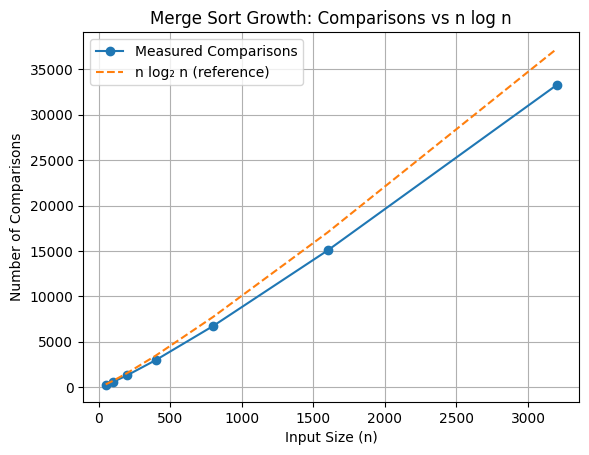

In [17]:
import random
import math
import matplotlib.pyplot as plt


def run_merge_sort_experiment(sizes, trials_per_size=20):
    """
    Runs merge sort on random lists of different sizes and
    records the average number of comparisons.
    """

    avg_comparisons = []

    for n in sizes:

        total = 0

        for _ in range(trials_per_size):

            data = [random.randint(1, 1000000) for _ in range(n)]
            counter = {"comparisons": 0}

            merge_sort(data, counter)

            total += counter["comparisons"]

        avg = total / trials_per_size
        avg_comparisons.append(avg)

        print(f"n={n:6}   avg comparisons={avg:10.2f}")

    return avg_comparisons


# Sizes of lists to test
sizes = [50, 100, 200, 400, 800, 1600, 3200]

# Run experiment
avg_comparisons = run_merge_sort_experiment(sizes, trials_per_size=25)


# Compute theoretical n log n curve for comparison
nlogn_curve = [n * math.log2(n) for n in sizes]


# Plot results
plt.figure()

plt.plot(sizes, avg_comparisons, marker='o', label="Measured Comparisons")
plt.plot(sizes, nlogn_curve, linestyle='--', label="n log₂ n (reference)")

plt.xlabel("Input Size (n)")
plt.ylabel("Number of Comparisons")
plt.title("Merge Sort Growth: Comparisons vs n log n")

plt.legend()
plt.grid(True)

plt.show()

In [20]:
import random
import time
import matplotlib.pyplot as plt


def generate_data(n, mode):
    """
    Generate data sets in different orders.
    """

    if mode == "random":
        return [random.randint(1, 1_000_000) for _ in range(n)]

    elif mode == "sorted":
        return list(range(n))

    elif mode == "reverse":
        return list(range(n, 0, -1))


def time_merge_sort(data):
    counter = {"comparisons": 0}
    start = time.perf_counter()
    merge_sort(data.copy(), counter)
    end = time.perf_counter()
    return end - start


def time_builtin_sort(data):
    start = time.perf_counter()
    sorted(data.copy())
    end = time.perf_counter()
    return end - start


def run_experiment(sizes, trials=20):

    results = {
        "merge_random": [],
        "merge_sorted": [],
        "merge_reverse": [],
        "builtin_random": [],
        "builtin_sorted": [],
        "builtin_reverse": [],
    }

    for n in sizes:

        totals = {key: 0 for key in results}

        for _ in range(trials):

            random_data = generate_data(n, "random")
            sorted_data = generate_data(n, "sorted")
            reverse_data = generate_data(n, "reverse")

            totals["merge_random"] += time_merge_sort(random_data)
            totals["merge_sorted"] += time_merge_sort(sorted_data)
            totals["merge_reverse"] += time_merge_sort(reverse_data)

            totals["builtin_random"] += time_builtin_sort(random_data)
            totals["builtin_sorted"] += time_builtin_sort(sorted_data)
            totals["builtin_reverse"] += time_builtin_sort(reverse_data)

        for key in results:
            results[key].append(totals[key] / trials)

        print(f"Completed size n = {n}")

    return results


sizes = [100, 500, 1000, 2000, 4000, 8000, 16_000, 32_000, 64_000]

results = run_experiment(sizes, trials=25)

Completed size n = 100
Completed size n = 500
Completed size n = 1000
Completed size n = 2000
Completed size n = 4000
Completed size n = 8000
Completed size n = 16000
Completed size n = 32000
Completed size n = 64000


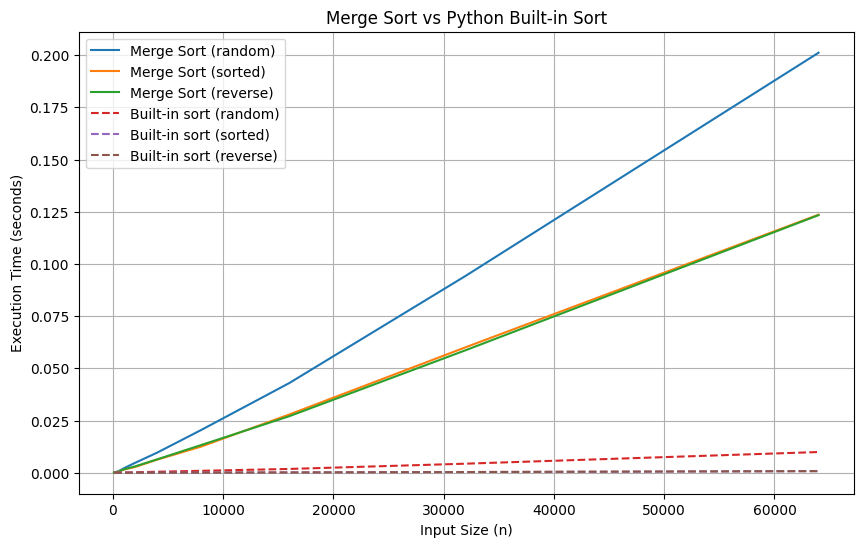

In [22]:
plt.figure(figsize=(10,6))

plt.plot(sizes, results["merge_random"], label="Merge Sort (random)")
plt.plot(sizes, results["merge_sorted"], label="Merge Sort (sorted)")
plt.plot(sizes, results["merge_reverse"], label="Merge Sort (reverse)")

plt.plot(sizes, results["builtin_random"], linestyle="--", label="Built-in sort (random)")
plt.plot(sizes, results["builtin_sorted"], linestyle="--", label="Built-in sort (sorted)")
plt.plot(sizes, results["builtin_reverse"], linestyle="--", label="Built-in sort (reverse)")

plt.xlabel("Input Size (n)")
plt.ylabel("Execution Time (seconds)")
plt.title("Merge Sort vs Python Built-in Sort")

plt.legend()
plt.grid(True)

plt.show()

# Understanding the Implementation

Merge sort works by repeatedly splitting the list into smaller pieces.

Example:

Original list (n = 8)

[38, 12, 57, 24, 9, 61, 33, 18]

Divide step:

[38, 12, 57, 24]    [9, 61, 33, 18]

Divide again:

[38, 12]  [57, 24]  [9, 61]  [33, 18]

Divide again:

[38] [12] [57] [24] [9] [61] [33] [18]

Single-element lists are already sorted.

The algorithm now performs the **merge step**.

Example merge:

[38] and [12]  →  [12, 38]

Each merge operation compares the smallest remaining elements from
two lists and appends the smaller value to the result list.

Because merging two lists of total size n requires at most n comparisons,
the overall work done during merging is proportional to n.

The recursion depth of the algorithm is log₂(n) because the list is
halved at each step.

Total work:

levels of recursion: log n  
work per level: n  

Total complexity:

O(n log n)

This makes merge sort dramatically faster than simple algorithms such as
bubble sort or insertion sort when sorting large lists.